<a href="https://colab.research.google.com/github/Ananya904/Youtube_trending_vedio_analysis/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis


**DATA COLLECTION**

*   Using a kaggle dataset Trending YouTube Video Statistics
*   Data includes the video title, channel title, publish time, tags, views, likes and dislikes, description, and comment count.




In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"ananyasingh114","key":"d79dc2bc8215dd0b39d9e78b0db8e0a4"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d datasnaek/youtube-new

Dataset URL: https://www.kaggle.com/datasets/datasnaek/youtube-new
License(s): CC0-1.0
youtube-new.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip youtube-new.zip -d data

Archive:  youtube-new.zip
replace data/CA_category_id.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os
print(os.listdir('data'))

['RU_category_id.json', 'DEvideos.csv', 'US_category_id.json', 'JPvideos.csv', 'MXvideos.csv', 'CAvideos.csv', 'JP_category_id.json', 'DE_category_id.json', 'FRvideos.csv', 'RUvideos.csv', 'GBvideos.csv', 'INvideos.csv', 'CA_category_id.json', 'GB_category_id.json', 'MX_category_id.json', 'KR_category_id.json', 'USvideos.csv', 'IN_category_id.json', 'FR_category_id.json', 'KRvideos.csv']


**Data Understanding**

>Exploratory Data Analysis (EDA) is a crucial step in any data science project. It's an approach to analyzing data sets to summarize their main characteristics, often with visual methods. The primary goal of EDA is to:
*  Understand the data: Get a feel for the data's structure, content, and quality.
* Uncover patterns and relationships: Identify trends, correlations, and anomalies.
*  Detect outliers and inconsistencies: Find unusual observations that might skew results.
*   Formulate hypotheses: Develop initial ideas about what the data might be telling you.







In [ ]:
import pandas as pd
df = pd.read_csv('data/INvideos.csv', encoding='latin-1')
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"à¤ªà¥à¤°à¤¿à¤¯à¤¡à¥à¤¸ à¤à¥ à¤¸à¤®à¤¯, à¤ª...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"à¤ªà¥à¤°à¤¿à¤¯à¤¡à¥à¤¸ à¤à¥ à¤¸à¤®à¤¯|""à¤ª...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"à¤ªà¥à¤°à¤¿à¤¯à¤¡à¥à¤¸ à¤à¥ à¤¸à¤®à¤¯, à¤ª..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...




> df.isnull().sum().sort_values(ascending=False)

isnull() → checks missing values

sum() → counts missing values per column

sort_values(ascending=False) → shows worst columns first

In [ ]:
df.shape
df.columns
df.info
df.isnull().sum().sort_values(ascending=False)

,0
category_name,326
title,0
tags,0
publish_time,0
views,0
likes,0
publish_hour,0
category_id,0
title_length,0
tag_count,0


choosing the columns we need

In [ ]:
df = df[['title', 'publish_time', 'tags', 'views', 'likes', 'category_id']]
df.head()


,title,publish_time,tags,views,likes,category_id
0,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,1
1,"à¤ªà¥à¤°à¤¿à¤¯à¤¡à¥à¤¸ à¤à¥ à¤¸à¤®à¤¯, à¤ª...",2017-11-13T05:43:56.000Z,"à¤ªà¥à¤°à¤¿à¤¯à¤¡à¥à¤¸ à¤à¥ à¤¸à¤®à¤¯|""à¤ª...",590101,735,25
2,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,24
3,Eruma Saani | Tamil vs English,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,23
4,why Samantha became EMOTIONAL @ Samantha naga ...,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,24




> df['category_id'].nunique()

category_id = numeric code for YouTube category

nunique() = number of unique categories


| Category ID | Category Name        |
| ----------- | -------------------- |
| **1**       | Film & Animation     |
| **2**       | Autos & Vehicles     |
| **10**      | Music                |
| **15**      | Pets & Animals       |
| **17**      | Sports               |
| **19**      | Travel & Events      |
| **20**      | Gaming               |
| **22**      | People & Blogs       |
| **23**      | Comedy               |
| **24**      | **Entertainment**    |
| **25**      | News & Politics      |
| **26**      | How-to & Style       |
| **27**      | Education            |
| **28**      | Science & Technology |



In [ ]:
df['category_id'].nunique()
df['category_id'].value_counts().head()


,count
category_id,
24,16712
25,5241
10,3858
23,3429
22,2624


**DATA CLEANING**


Datetime Conversion:-


Converting published_at into a proper datetime format and extract the hour of upload.

In [ ]:
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df['publish_hour'] = df['publish_time'].dt.hour
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df['publish_hour'] = df['publish_time'].dt.hour
df[['publish_time','publish_hour']].head()

,publish_time,publish_hour
0,2017-11-12 12:20:39+00:00,12
1,2017-11-13 05:43:56+00:00,5
2,2017-11-12 15:48:08+00:00,15
3,2017-11-12 07:08:48+00:00,7
4,2017-11-13 01:14:16+00:00,1


**Feature Engineering**

> Feature Engineering, also known as feature creation, is the process of transforming raw data into features that better represent the underlying problem to the predictive models, resulting in improved model accuracy on unseen data.

> Essentially, it's about extracting new information from your existing data that might be more useful for analysis or modeling than the original raw data.

* publish_hour-> Hour when video was uploaded
*  title_length	->Length of video title
*  tag_count->	Number of tags
*   like_ratio->	Likes / Views
*  category_name->	Human-readable category








In [ ]:
df['title_length']=df['title'].str.len()
df['tag_count']=df['tags'].apply(lambda x:len(str(x).split('|')))
df['like_ratio']=df['likes']/df['views']
df=df[df['views']>0]
df.dropna(inplace=True)
df[['title_length','tag_count','like_ratio']].head(15)

,title_length,tag_count,like_ratio
0,81,15,0.030982
1,148,19,0.001246
2,58,14,0.004243
3,30,20,0.056614
4,88,11,0.001060
5,91,22,0.016148
6,96,18,0.022291
7,96,26,0.012536
8,97,21,0.004398
9,34,23,0.061709


df['tag_count']=df['tags'].apply(lambda x:len(str(x).split('|')))

What it does
*  Converts tags to string
*   Splits tags using |
*  Counts how many tags


df=df[df['views']>0]

*  to prevent Division by zero error




**Golden Hour Analysis**


In [ ]:
hourly_view=df.groupby('publish_hour')['views'].mean()
hourly_view

,views
publish_hour,
0,6.975628e+05
1,1.252534e+06
2,7.651132e+05
3,1.173203e+06
4,1.276174e+06
5,1.270203e+06
6,1.110944e+06
7,1.312904e+06
8,8.989955e+05


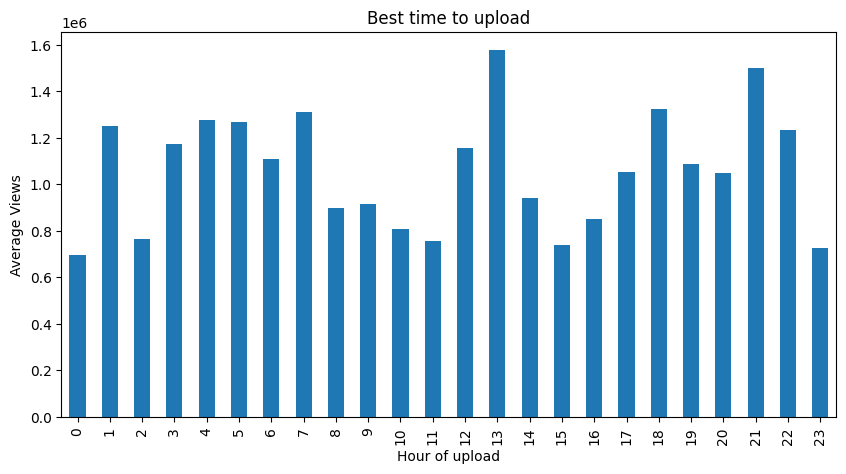

In [ ]:
import matplotlib.pyplot as plt

hourly_view.plot(kind='bar', figsize=(10,5))
plt.xlabel('Hour of upload')
plt.ylabel('Average Views')
plt.title("Best time to upload")
plt.show()

Finding optimal number of tags for higer views

In [ ]:
bins = [0, 5, 15,30,60,100]
labels = ['0-5', '6-15', '16-30','31-60','60+']

df['tag_bucket']= pd.cut(df['tag_count'],bins=bins,labels=labels)

df.groupby('tag_bucket')['views'].mean()

/tmp/ipython-input-332504640.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tag_bucket')['views'].mean()


,views
tag_bucket,
0-5,6.546318e+05
6-15,8.420917e+05
16-30,1.246850e+06
31-60,1.172605e+06
60+,4.381036e+05


/tmp/ipython-input-3223459013.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tag_views = df.groupby('tag_bucket')['views'].mean()


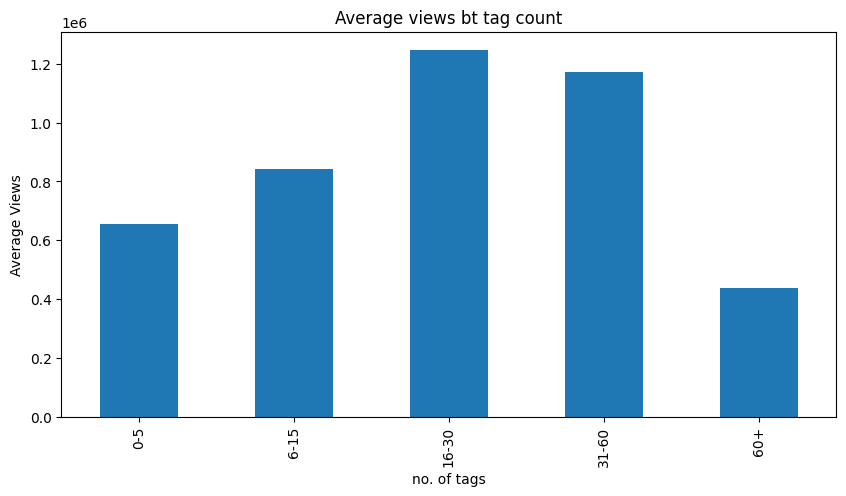

In [ ]:
import matplotlib.pyplot as plt

tag_views = df.groupby('tag_bucket')['views'].mean()

plt.figure(figsize=(10,5))
tag_views.plot(kind='bar')
plt.xlabel('no. of tags')
plt.ylabel('Average Views')
plt.title('Average views bt tag count')
plt.show()

Title Length vs Views (Scatter Plot)

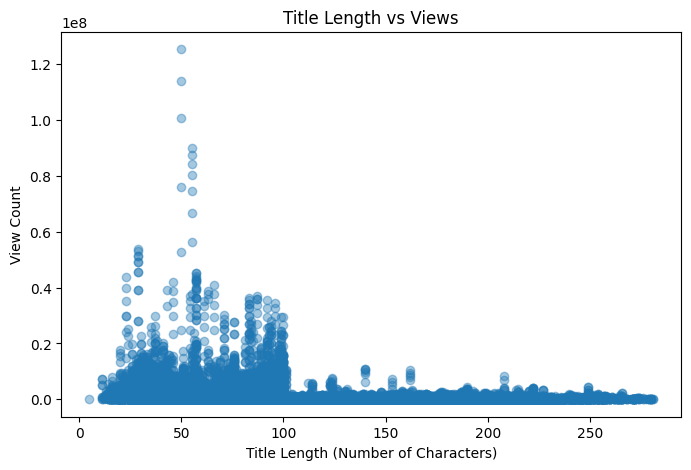

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['title_length'], df['views'], alpha=0.4)

plt.xlabel('Title Length (Number of Characters)')
plt.ylabel('View Count')
plt.title('Title Length vs Views')

plt.show()


Correlation – Title Length vs Views

df[['title_length', 'views']].corr()


*   Measures relationship strength between variables

*  Value range: -1 to +1



In [ ]:
df[['title_length', 'views']].corr()


,title_length,views
title_length,1.000000,-0.118267
views,-0.118267,1.000000


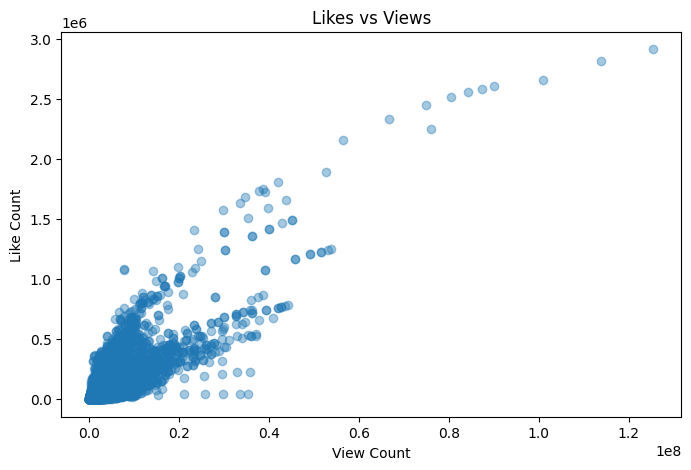

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['views'], df['likes'], alpha=0.4)

plt.xlabel('View Count')
plt.ylabel('Like Count')
plt.title('Likes vs Views')

plt.show()


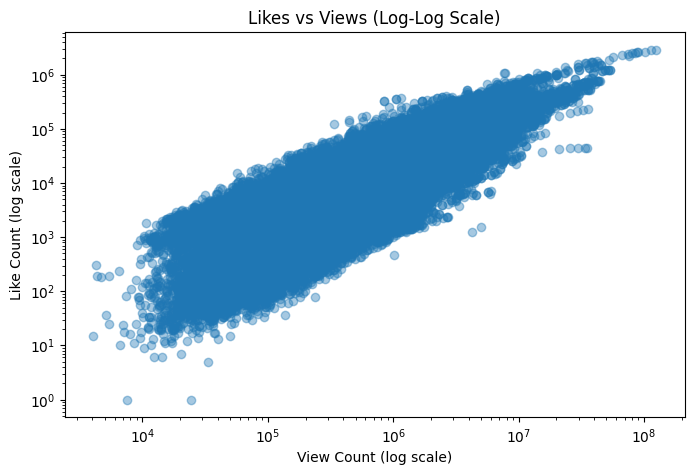

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['views'], df['likes'], alpha=0.4)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('View Count (log scale)')
plt.ylabel('Like Count (log scale)')
plt.title('Likes vs Views (Log-Log Scale)')

plt.show()


Different Country Upload Time Comparison

In [ ]:
import pandas as pd

countries = {
    'India': 'data/INvideos.csv',
    'USA': 'data/USvideos.csv',
    'UK': 'data/GBvideos.csv',
    'Canada': 'data/CAvideos.csv'
}

dfs = []

for country, path in countries.items():
    temp_df = pd.read_csv(path, encoding='latin-1')
    temp_df = temp_df[['publish_time', 'views']]

    temp_df['publish_time'] = pd.to_datetime(temp_df['publish_time'], errors='coerce')
    temp_df['publish_hour'] = temp_df['publish_time'].dt.hour
    temp_df['country'] = country

    temp_df = temp_df[temp_df['views'] > 0]
    temp_df.dropna(inplace=True)

    dfs.append(temp_df)

multi_df = pd.concat(dfs)
multi_df.head(10)


,publish_time,views,publish_hour,country
0,2017-11-12 12:20:39+00:00,1096327,12,India
1,2017-11-13 05:43:56+00:00,590101,5,India
2,2017-11-12 15:48:08+00:00,473988,15,India
3,2017-11-12 07:08:48+00:00,1242680,7,India
4,2017-11-13 01:14:16+00:00,464015,1,India
5,2017-11-10 04:29:50+00:00,6106669,4,India
6,2017-11-11 16:41:15+00:00,5718766,16,India
7,2017-11-11 06:14:19+00:00,10588371,6,India
8,2017-11-13 04:42:26+00:00,118223,4,India
9,2017-11-12 04:30:01+00:00,969030,4,India


In [ ]:
hourly_country_views = (
    multi_df
    .groupby(['country', 'publish_hour'])['views']
    .mean()
    .reset_index()
)

hourly_country_views.head()


,country,publish_hour,views
0,Canada,0,9.823300e+05
1,Canada,1,1.073117e+06
2,Canada,2,8.936016e+05
3,Canada,3,1.146501e+06
4,Canada,4,2.158562e+06


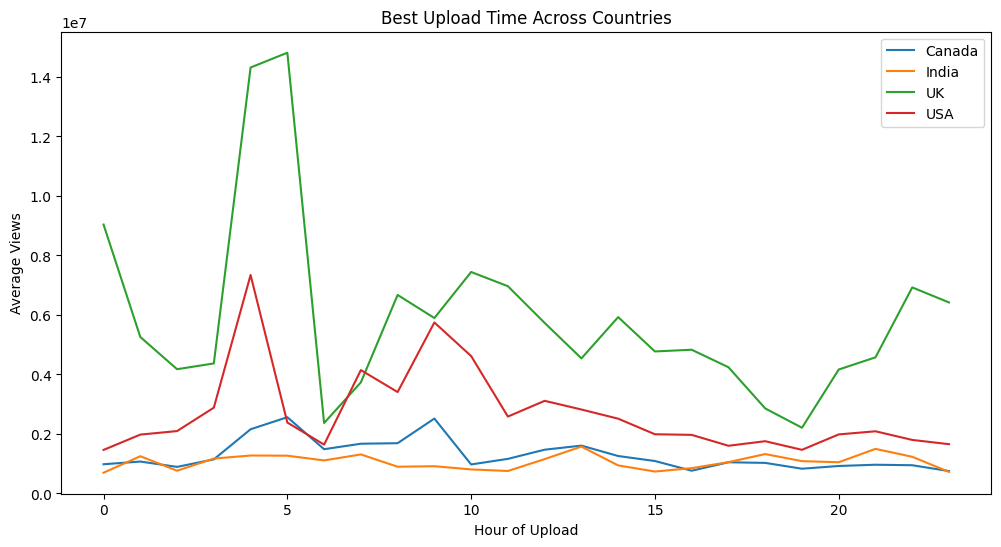

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for country in hourly_country_views['country'].unique():
    country_data = hourly_country_views[hourly_country_views['country'] == country]
    plt.plot(country_data['publish_hour'], country_data['views'], label=country)

plt.xlabel('Hour of Upload')
plt.ylabel('Average Views')
plt.title('Best Upload Time Across Countries')
plt.legend()
plt.show()


Category-wise Virality Analysis

In [ ]:
category_map = {
    1: 'Film & Animation',
    2: 'Autos & Vehicles',
    10: 'Music',
    15: 'Pets & Animals',
    17: 'Sports',
    19: 'Travel & Events',
    20: 'Gaming',
    22: 'People & Blogs',
    23: 'Comedy',
    24: 'Entertainment',
    25: 'News & Politics',
    26: 'How-to & Style',
    27: 'Education',
    28: 'Science & Technology'
}

df['category_name'] = df['category_id'].map(category_map)
df[['category_id', 'category_name']].head()


,category_id,category_name
0,1,Film & Animation
1,25,News & Politics
2,24,Entertainment
3,23,Comedy
4,24,Entertainment


In [ ]:
category_views = (
    df.groupby('category_name')['views']
    .mean()
    .sort_values(ascending=False)
)

category_views


,views
category_name,
Gaming,4.162462e+06
Music,2.631116e+06
Film & Animation,2.320356e+06
Sports,1.887755e+06
Pets & Animals,1.626581e+06
Entertainment,9.645997e+05
How-to & Style,8.725960e+05
Science & Technology,8.643316e+05
Comedy,8.421324e+05


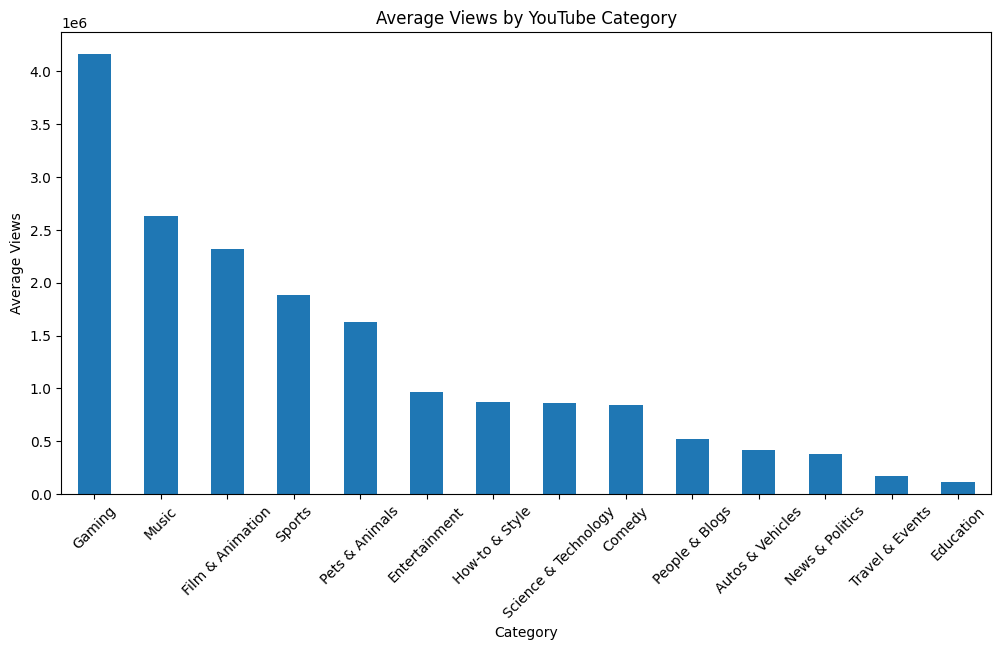

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
category_views.plot(kind='bar')

plt.xlabel('Category')
plt.ylabel('Average Views')
plt.title('Average Views by YouTube Category')
plt.xticks(rotation=45)
plt.show()


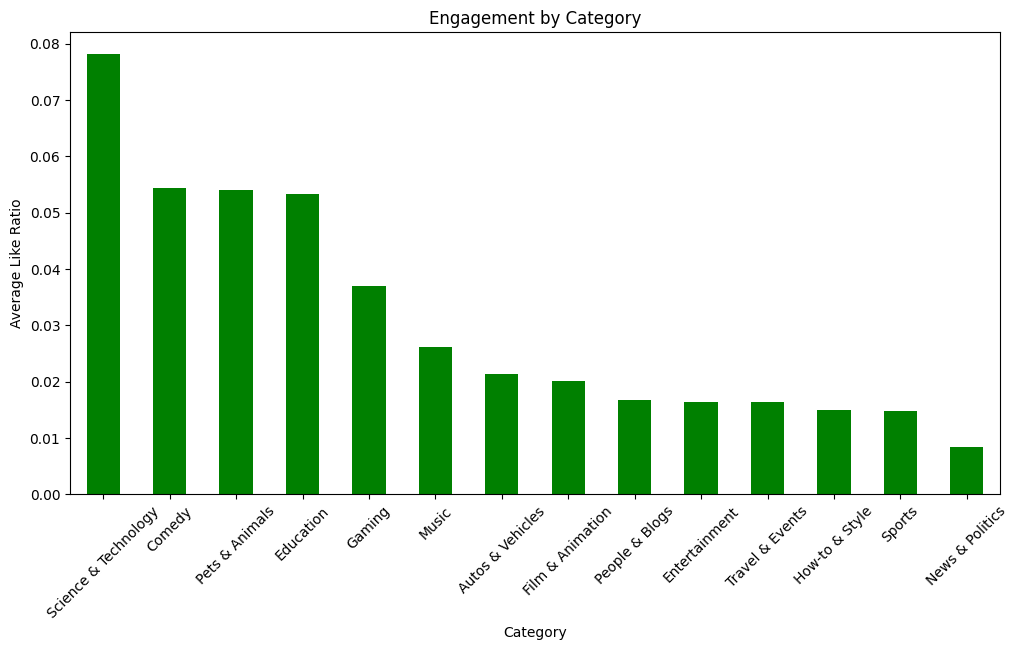

In [ ]:
category_engagement = (
    df.groupby('category_name')['like_ratio']
    .mean()
    .sort_values(ascending=False)
)

category_engagement

plt.figure(figsize=(12,6))
category_engagement.plot(kind='bar', color='green')

plt.xlabel('Category')
plt.ylabel('Average Like Ratio')
plt.title('Engagement by Category')
plt.xticks(rotation=45)
plt.show()


In [ ]:
import pandas as pd

countries = {
    'India': 'data/INvideos.csv',
    'USA': 'data/USvideos.csv',
    'UK': 'data/GBvideos.csv',
    'Canada': 'data/CAvideos.csv'
}

category_map = {
    1: 'Film & Animation',
    2: 'Autos & Vehicles',
    10: 'Music',
    15: 'Pets & Animals',
    17: 'Sports',
    19: 'Travel & Events',
    20: 'Gaming',
    22: 'People & Blogs',
    23: 'Comedy',
    24: 'Entertainment',
    25: 'News & Politics',
    26: 'How-to & Style',
    27: 'Education',
    28: 'Science & Technology'
}

dfs = []

for country, path in countries.items():
    temp = pd.read_csv(path, encoding='latin-1')
    temp = temp[['category_id', 'views']]

    temp['category_name'] = temp['category_id'].map(category_map)
    temp['country'] = country

    temp = temp[temp['views'] > 0]
    temp.dropna(inplace=True)

    dfs.append(temp)

cc_df = pd.concat(dfs)
cc_df.head()


,category_id,views,category_name,country
0,1,1096327,Film & Animation,India
1,25,590101,News & Politics,India
2,24,473988,Entertainment,India
3,23,1242680,Comedy,India
4,24,464015,Entertainment,India


In [ ]:
country_category_views = (
    cc_df
    .groupby(['country', 'category_name'])['views']
    .mean()
    .reset_index()
)

country_category_views.head()


,country,category_name,views
0,Canada,Autos & Vehicles,5.667594e+05
1,Canada,Comedy,9.828886e+05
2,Canada,Education,5.366028e+05
3,Canada,Entertainment,1.016372e+06
4,Canada,Film & Animation,1.426729e+06


In [ ]:
pivot_table = country_category_views.pivot(
    index='category_name',
    columns='country',
    values='views'
)

pivot_table


country,Canada,India,UK,USA
category_name,,,,
Autos & Vehicles,5.667594e+05,4.220101e+05,1.487392e+06,1.355965e+06
Comedy,9.828886e+05,8.421324e+05,2.167430e+06,1.480308e+06
Education,5.366028e+05,1.186094e+05,9.721894e+05,7.129408e+05
Entertainment,1.016372e+06,9.645997e+05,3.264608e+06,2.067883e+06
Film & Animation,1.426729e+06,2.320356e+06,3.245133e+06,3.106250e+06
Gaming,9.237592e+05,4.162462e+06,9.768566e+05,2.620831e+06
How-to & Style,7.826839e+05,8.725960e+05,6.173004e+05,9.837301e+05
Music,3.532525e+06,2.631116e+06,1.244444e+07,6.201003e+06
News & Politics,3.882207e+05,3.805121e+05,1.150311e+06,5.925877e+05


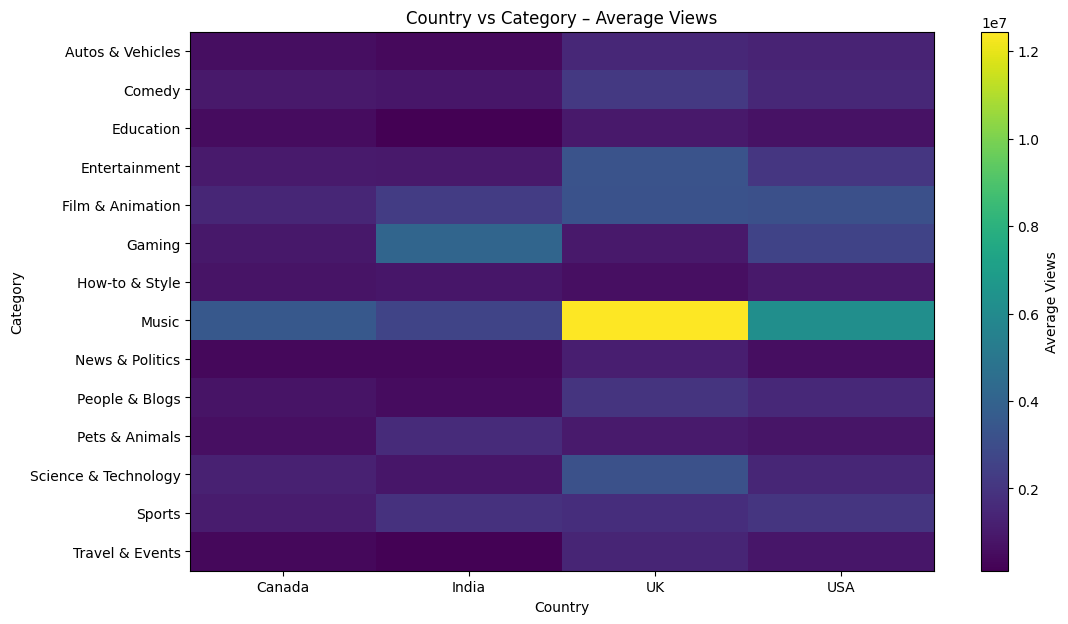

In [ ]:
plt.figure(figsize=(12,7))
plt.imshow(pivot_table, aspect='auto')

plt.colorbar(label='Average Views')
plt.xticks(range(len(pivot_table.columns)), pivot_table.columns)
plt.yticks(range(len(pivot_table.index)), pivot_table.index)

plt.xlabel('Country')
plt.ylabel('Category')
plt.title('Country vs Category – Average Views')

plt.show()


In [ ]:
dfs = []

for country, path in countries.items():
    temp = pd.read_csv(path, encoding='latin-1')
    temp = temp[['category_id', 'views', 'likes']]

    temp['like_ratio'] = temp['likes'] / temp['views']
    temp['category_name'] = temp['category_id'].map(category_map)
    temp['country'] = country

    temp = temp[temp['views'] > 0]
    temp.dropna(inplace=True)

    dfs.append(temp)

eng_df = pd.concat(dfs)
eng_df.head()


,category_id,views,likes,like_ratio,category_name,country
0,1,1096327,33966,0.030982,Film & Animation,India
1,25,590101,735,0.001246,News & Politics,India
2,24,473988,2011,0.004243,Entertainment,India
3,23,1242680,70353,0.056614,Comedy,India
4,24,464015,492,0.001060,Entertainment,India


In [ ]:
category_engagement = (
    eng_df
    .groupby('category_name')['like_ratio']
    .mean()
    .sort_values(ascending=False)
)

category_engagement


,like_ratio
category_name,
Comedy,0.048086
Education,0.043697
How-to & Style,0.043047
Music,0.040133
Gaming,0.039472
Science & Technology,0.038507
Pets & Animals,0.035656
People & Blogs,0.032632
Travel & Events,0.028415


In [ ]:
country_engagement = (
    eng_df
    .groupby('country')['like_ratio']
    .mean()
    .sort_values(ascending=False)
)

country_engagement


,like_ratio
country,
USA,0.034425
UK,0.033745
Canada,0.033475
India,0.022089


In [ ]:
pivot_engagement = (
    eng_df
    .groupby(['category_name', 'country'])['like_ratio']
    .mean()
    .unstack()
)

pivot_engagement


country,Canada,India,UK,USA
category_name,,,,
Autos & Vehicles,0.032294,0.021398,0.018627,0.016903
Comedy,0.051957,0.054288,0.036412,0.043884
Education,0.044029,0.053338,0.038604,0.037760
Entertainment,0.026828,0.016418,0.030202,0.028527
Film & Animation,0.029435,0.020042,0.026875,0.027419
Gaming,0.049498,0.036884,0.033024,0.037300
How-to & Style,0.050328,0.014909,0.043616,0.044993
Music,0.048562,0.026051,0.038300,0.047565
News & Politics,0.022047,0.008313,0.020993,0.012695


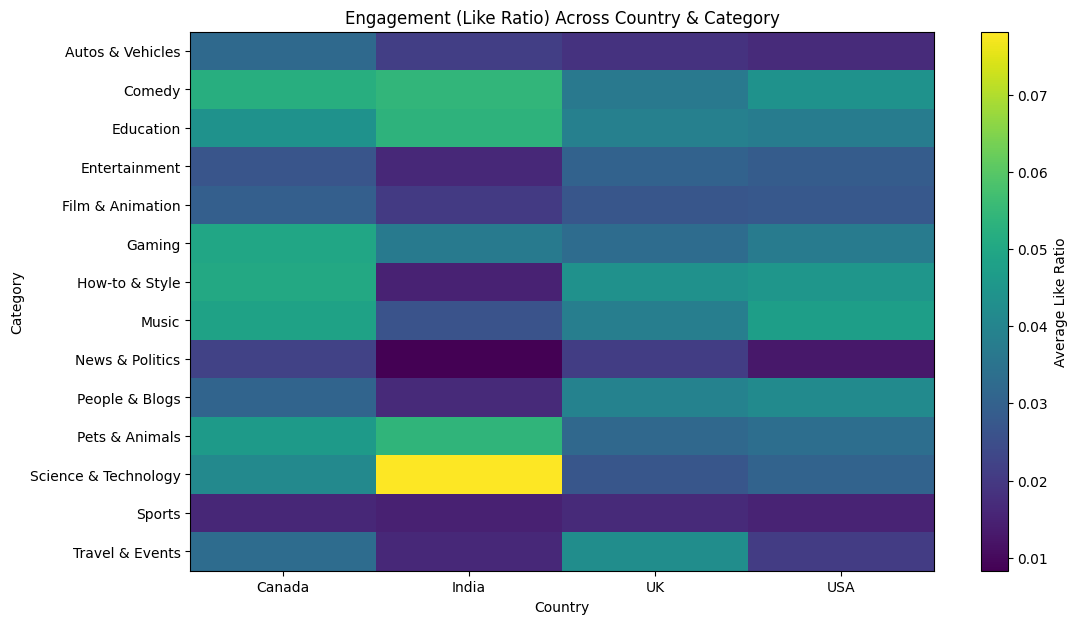

In [ ]:
plt.figure(figsize=(12,7))
plt.imshow(pivot_engagement, aspect='auto')

plt.colorbar(label='Average Like Ratio')
plt.xticks(range(len(pivot_engagement.columns)), pivot_engagement.columns)
plt.yticks(range(len(pivot_engagement.index)), pivot_engagement.index)

plt.xlabel('Country')
plt.ylabel('Category')
plt.title('Engagement (Like Ratio) Across Country & Category')

plt.show()


In [ ]:
final_df = eng_df.copy()

final_df = final_df[['country', 'category_name', 'views', 'likes', 'like_ratio']]
final_df.to_csv('youtube_trending_analysis.csv', index=False)

hourly_country_views.to_csv('hourly_upload_performance.csv', index=False)
country_category_views.to_csv('category_performance.csv', index=False)
eng_df.to_csv('engagement_data.csv', index=False)


from google.colab import files

files.download('hourly_upload_performance.csv')
files.download('category_performance.csv')
files.download('engagement_data.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>